In [1]:
import glob
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import SBM.utils.utils as ut

In [7]:
list_of_dicts = []

for f in glob.glob("../models/SectorSubaln0/*.npy"):
    n_chains = int(f.split("_")[3][6:])
    filename = f
    list_of_dicts.append({"n_chains": n_chains, "file": f})

df = pd.DataFrame(list_of_dicts)

In [8]:
nchain_values = []
stdnorms_means = []
stdnorms_stds = []
bootstraps = 20
for file in df.sort_values(by="n_chains")["file"]:
    n_chains = int(file.split("_")[3][6:])
    model = np.load(file, allow_pickle=True).item()
    Js = []
    for W_all in model["W_all"]:
        J, h = ut.Jw(W_all, q=21)
        Js.append(J)
    Js = np.array(Js)
    stdnorms_bootstrap = []
    for bootstrap in range(bootstraps):
        Js_bootstrap = Js[np.random.randint(0, 10, size=10), :]
        stdnorm_bootstrap = np.linalg.norm(np.std(Js_bootstrap, axis=0).flatten())
        stdnorms_bootstrap.append(stdnorm_bootstrap)
    stdnorms_means.append(np.mean(stdnorms_bootstrap))
    stdnorms_stds.append(np.std(stdnorms_bootstrap) / np.sqrt(bootstraps))
    nchain_values.append(n_chains)

In [9]:
nchain_values = np.array(nchain_values)[1:]
stdnorms_means = np.array(stdnorms_means)[1:]
stdnorms_stds = np.array(stdnorms_stds)[1:]

In [10]:
nchain_values, stdnorms_means, stdnorms_stds

(array([   2,    4,    8,   16,   32,   64,  128,  256,  512, 1024, 2048,
        4096]),
 array([18.8224427 , 14.51411852, 12.41373156,  9.84581319, 12.21126629,
         8.66668617,  9.52610718,  9.27575861, 10.68206149, 15.54540154,
        20.68440408, 26.9742862 ]),
 array([0.62282749, 0.21801315, 0.10771816, 0.11405735, 0.10941091,
        0.11047588, 0.10152168, 0.06750262, 0.09336914, 0.18660582,
        0.31316043, 0.95829058]))

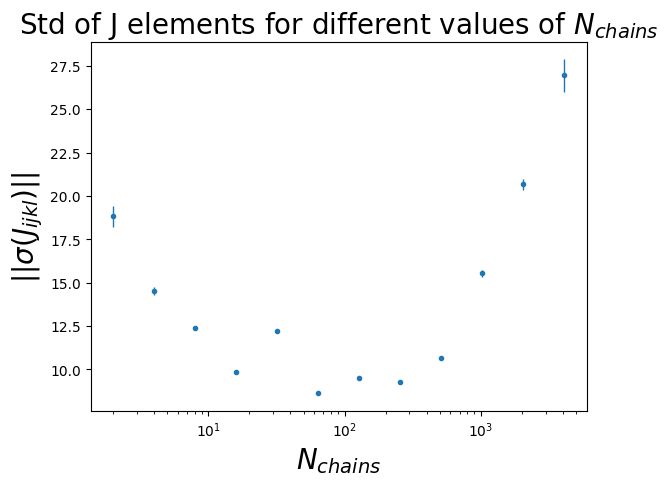

In [11]:
mpl.rcParams['text.usetex'] = False
mpl.rcParams['axes.titlesize'] = 20
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['lines.linewidth'] = 1

plt.figure()
plt.errorbar(nchain_values, stdnorms_means, yerr=stdnorms_stds, fmt='.')
plt.xscale("log")
plt.xlabel(r"$N_{chains}$")
plt.ylabel(r"$||\sigma(J_{ijkl})||$")
plt.title("Std of J elements for different values of $N_{chains}$")
plt.show()